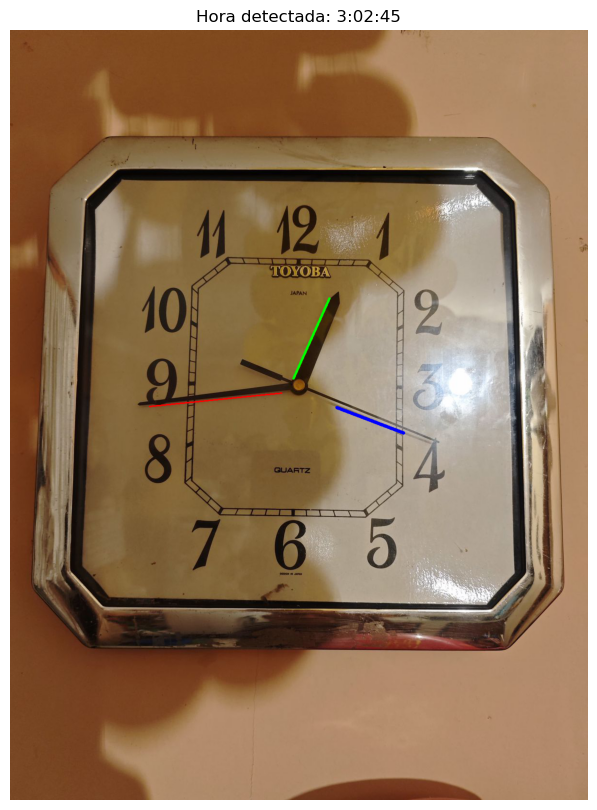

La hora detectada es: 3:02:45


In [14]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('pruebareloj17.jpeg')
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
gris = cv2.GaussianBlur(gris, (5, 5), 1)
gris = cv2.equalizeHist(gris)

bordes = cv2.Canny(gris, 50, 150)

lineas = cv2.HoughLinesP(bordes, 1, np.pi/180, threshold=80, minLineLength=50, maxLineGap=10)

centro_x = imagen_bgr.shape[1] // 2
centro_y = imagen_bgr.shape[0] // 2

manecillas = [] #lista donde se guarda las posibles manecillas y q se obtiene cada eje
if lineas is not None:
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]
        
        dist1 = np.hypot(x1 - centro_x, y1 - centro_y)
        dist2 = np.hypot(x2 - centro_x, y2 - centro_y)
        
        if dist1 > dist2:
            x_lejos, y_lejos, d_far = x1, y1, dist1
            x_cerca, y_cerca, d_cerca = x2, y2, dist2
        else:
            x_lejos, y_lejos, d_far = x2, y2, dist2
            x_cerca, y_cerca, d_cerca = x1, y1, dist1

        if d_cerca < 100 and d_far > 40: #acepta si el origen esta cerca del centro
            dx = x_lejos - centro_x
            dy = centro_y - y_lejos
            angulo = np.degrees(np.arctan2(dy, dx))
            angulo = (90 - angulo) % 360 #jugamos con el angulo 
            
            manecillas.append({
                'puntos': (x_cerca, y_cerca, x_lejos, y_lejos),
                'longitud': d_far,
                'angulo': angulo
            })

#nuevo
manecillas_agrupadas = []
for m in manecillas:
    agrupado = False
    for grupo in manecillas_agrupadas:
        diff = abs(grupo['angulo'] - m['angulo'])
        diff = min(diff, 360 - diff)
        
        if diff < 15:
            if m['longitud'] > grupo['longitud']:
                grupo['longitud'] = m['longitud']
                grupo['puntos'] = m['puntos']
                grupo['angulo'] = m['angulo']
            agrupado = True
            break
            
    if not agrupado:
        manecillas_agrupadas.append(dict(m))

if len(manecillas_agrupadas) >= 3:
    manecillas_agrupadas.sort(key=lambda x: x['longitud'], reverse=True)
    manecillas_principales = manecillas_agrupadas[:3]
    
    manecillas_principales.sort(key=lambda x: x['longitud'])
    horario = manecillas_principales[0]
    minutero = manecillas_principales[1]
    segundero = manecillas_principales[2]
    
    hora = int((horario['angulo'] / 30) % 12)
    minutos = int((minutero['angulo'] / 6) % 60)
    segundos = int((segundero['angulo'] / 6) % 60)

    fraccion_hora = (horario['angulo'] / 30) % 12
    if abs(fraccion_hora - hora) > 0.5:
        hora = (hora + 1) % 12
    if hora == 0: hora = 12

    imagen_resultado = imagen_rgb.copy()
    
    cv2.line(imagen_resultado,
             (horario['puntos'][0], horario['puntos'][1]),
             (horario['puntos'][2], horario['puntos'][3]),
             (0, 0, 255), 5)  
    cv2.line(imagen_resultado,
             (minutero['puntos'][0], minutero['puntos'][1]),
             (minutero['puntos'][2], minutero['puntos'][3]),
             (0, 255, 0), 4)
    #segundero
    cv2.line(imagen_resultado,
             (segundero['puntos'][0], segundero['puntos'][1]),
             (segundero['puntos'][2], segundero['puntos'][3]),
             (255, 0, 0), 2)  

    plt.figure(figsize=(10, 10))
    plt.imshow(imagen_resultado)
    plt.title(f'Hora detectada: {hora}:{minutos:02d}:{segundos:02d}')
    plt.axis('off')
    plt.show()

    print(f"La hora detectada es: {hora}:{minutos:02d}:{segundos:02d}")
else:
    print(f"No se detectaron suficientes manecillas :(")

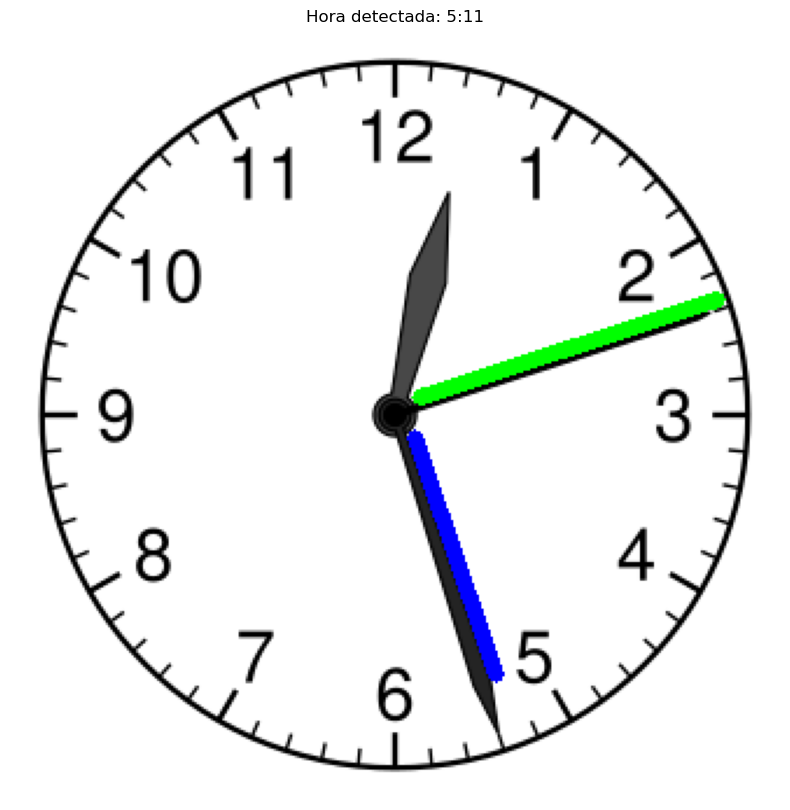

La hora detectada es: 5:11


In [45]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('pruebareloj12.png')
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

gris = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2GRAY)
gris = cv2.GaussianBlur(gris, (5, 5), 1)
gris = cv2.equalizeHist(gris)

# detección de bordes
bordes = cv2.Canny(gris, 50, 150)

#  líneas
lineas = cv2.HoughLinesP(bordes, 1, np.pi/180, threshold=80, minLineLength=50, maxLineGap=10)

# centro del reloj
centro_x = imagen_bgr.shape[1] // 2
centro_y = imagen_bgr.shape[0] // 2

# calcular ángulo
def calcular_angulo(x1, y1, x2, y2):
    dist1 = np.hypot(x1 - centro_x, y1 - centro_y)
    dist2 = np.hypot(x2 - centro_x, y2 - centro_y)
    if dist1 > dist2:
        dx = x1 - centro_x
        dy = centro_y - y1
    else:
        dx = x2 - centro_x
        dy = centro_y - y2
    angulo = np.degrees(np.arctan2(dy, dx))
    angulo = (90 - angulo) % 360
    return angulo

manecillas = []
if lineas is not None:
    for linea in lineas:
        x1, y1, x2, y2 = linea[0]
        longitud = np.hypot(x2 - x1, y2 - y1)
        distancia_centro = min(np.hypot(x1 - centro_x, y1 - centro_y),np.hypot(x2 - centro_x, y2 - centro_y))
        if distancia_centro < 100 and 40 < longitud < 300:
            angulo = calcular_angulo(x1, y1, x2, y2)
            manecillas.append({
                'puntos': (x1, y1, x2, y2),
                'longitud': longitud,
                'angulo': angulo
            })

if len(manecillas) >= 2:
    # más corta = horario, más larga = minutero
    manecillas.sort(key=lambda x: x['longitud'])
    horario = manecillas[0]
    minutero = manecillas[-1]
    
    # hora y minutos
    hora = int((horario['angulo'] / 30) % 12)
    minutos = int((minutero['angulo'] / 6) % 60)

    # la hora
    fraccion_hora = (horario['angulo'] / 30) % 12
    if abs(fraccion_hora - hora) > 0.5:
        hora = (hora + 1) % 12


    imagen_resultado = imagen_rgb.copy()
   # cv2.circle(imagen_resultado, (centro_x, centro_y), 5, (0, 0, 255), -1)
    cv2.line(imagen_resultado,
             (horario['puntos'][0], horario['puntos'][1]),
             (horario['puntos'][2], horario['puntos'][3]),
             (0, 0, 255), 5)  
    cv2.line(imagen_resultado,
             (minutero['puntos'][0], minutero['puntos'][1]),
             (minutero['puntos'][2], minutero['puntos'][3]),
             (0, 255, 0), 5)  

    plt.figure(figsize=(10, 10))
    plt.imshow(imagen_resultado)
    plt.title(f'Hora detectada: {hora}:{minutos:02d}')
    plt.axis('off')
    plt.show()

    print(f"La hora detectada es: {hora}:{minutos:02d}")
else:
    print("No se detectaron suficientes manecillas.")
